In [5]:
import OptimalBattery.simulate as sim
import torch as pt
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import OptimalBattery.plot as plot
from scipy.stats import pearsonr
from OptimalBattery.global_config import save_dir
import pandas as pd
from scipy.stats import gamma
import OptimalBattery.util as ut
import OptimalBattery.estimate as et

# Start with a base U 

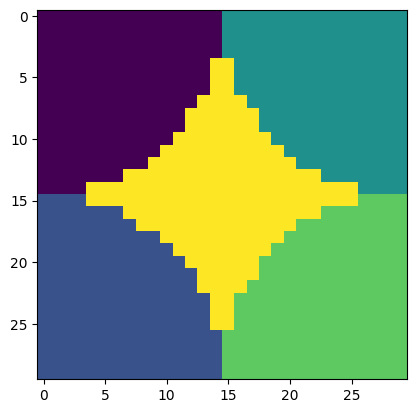

In [6]:
device = pt.device("cuda" if pt.cuda.is_available() else "cpu")

grid_height = 30
grid_width = 30

U_true_5 = sim.make_U_spatial(height=grid_height, width=grid_width, K_main= 5)
U_true_5 = pt.from_numpy(U_true_5).to(device)

labels = pt.argmax(U_true_5, axis=0)          
label_map = labels.reshape(grid_height, grid_width)           
plt.imshow(label_map.cpu().numpy())
plt.show()

In [7]:
U_individuals = sim.make_U_individuals(U_true_5,grid_width,grid_height, n_individuals=100,
                            size_range = (120,240),seed=1,device=device)

# make collpased versions of U_individuals (Region of interest and everything else)
U_individuals_collapsed = []
target_indices = [4]
for U_ind in U_individuals:
    U_collapsed = sim.collapse_U(U_ind, target_parcels_indices=target_indices)
    U_individuals_collapsed.append(U_collapsed)

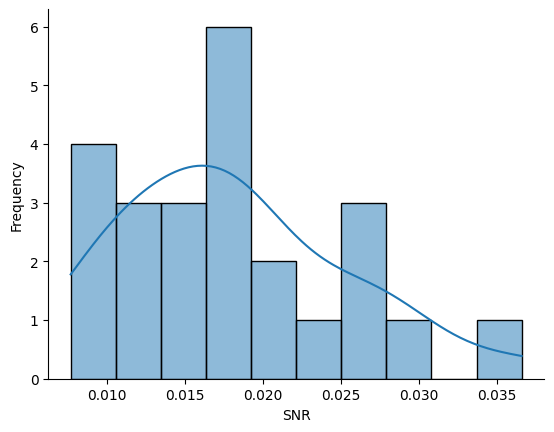

In [8]:
snr_list = [0.0196991187488852, 0.0291119097017132, 0.009868315372056239, 0.02666920728512233, 0.012530722513964174, 0.023969897215134296, 0.026436919129805385, 0.019008834666825788, 0.014048736255142842, 0.018222607813836222, 0.03655696258923394, 0.00945854991438873, 0.017826522554411507, 0.016721016465301754, 0.01134745499645742, 0.027609353003180823, 0.019002938368900588, 0.014779159602009994, 0.019332472019233885, 0.012547128382596882, 0.015449975415808167, 0.017610806336780898, 0.009659853650544005, 0.007693769241799343]
sns.histplot(snr_list, bins=10, kde=True)
plt.xlabel("SNR")
plt.ylabel("Frequency")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
# save
# plt.savefig(f"{save_dir}/single_vs_multi/snr_distribution.pdf", bbox_inches='tight')
plt.show()


In [9]:
def sim_single_vs_multi(U_individuals,U_individuals_collapsed,base_noise,snr_ratios,seed = 0):
    """ Single simulation comparing contrast localization vs multi-task localization
    args:
        U_individuals: list of individual parcellations (each is a tensor of shape (K, P))
        U_individuals_collapsed: list of individual collapsed parcellations (each is a tensor of shape (2, P))
        base_noise: base noise level
        snr_ratios: list of snr ratios to sample from gamma distribution (from empirical data mdtb1)
        seed: random seed for reproducibility
    returns:
        results_df: DataFrame with the results of the simulations
    """
    results_df = pd.DataFrame()
    max_n_task = 5

    # fit gamma to snr ratios
    shape, loc, scale = gamma.fit(snr_ratios, floc=0)  

    # generate Vs that are orthonal on the column and row (has to be square matrix)
    rng= np.random.default_rng(seed)
    V = np.eye(5, 5)
    A = rng.normal(size=(5, 5))
    Q, _ = np.linalg.qr(A)
    V_lib = Q @ V
    V_lib = pt.tensor(V_lib, dtype=pt.float64, device=device)


    max_idx, min_idx = sim.find_max_contrast_against_all(V_lib, 4)
    combination = [max_idx, min_idx]

    # get the V localizer
    V_battery = V_lib[combination,:]
    n_task = V_battery.shape[0]

    # Battery-level noise (same for all subs)
    weighted_noise_std = sim.get_weighted_noise_std(n_task=n_task, max_n_task=max_n_task, noise=base_noise)
    battery_noise = rng.normal(0, weighted_noise_std, (V_battery.shape[0], U_individuals[0].shape[1]))
    battery_noise = pt.tensor(battery_noise, dtype=pt.float64, device=device)
    
    thresholds = np.linspace(0.01,0.5,50)
    for threshold in thresholds:
        print(f"Simulating for threshold: {threshold:.3f}")
        for individual in range(len(U_individuals)):
            # get the data for the parcellation estimation and add noise
            Y_battery = V_battery @ U_individuals[individual] 

            # subject-specific SNR variation
            rng_sub = np.random.default_rng(seed= seed + individual)
            snr_factor = rng_sub.gamma(shape, scale=scale)
            Y_battery = Y_battery * np.sqrt(snr_factor)

            # add battery-level noise
            Y_battery = Y_battery + battery_noise

            U_hat = sim.make_thresholded_contrast(Y_battery[0,:], Y_battery[1,:],threshold= threshold,mode='absolute')

            predicted_size = U_hat[0, :].sum().item()

            # Evaluate the contrast
            accuracy = sim.get_dice_single(U_individuals_collapsed[individual], U_hat)
            D_ev = pd.DataFrame()
            D_ev['type'] = 'contrast_T'
            D_ev['n_tasks'] = [n_task]
            D_ev['snr_factor'] = [snr_factor]
            D_ev['individual'] = [individual]
            D_ev['accuracy'] = accuracy
            D_ev['predicted_size'] = predicted_size
            D_ev['true_size'] = U_individuals_collapsed[individual][0,:].sum().item()
            D_ev['true_everything_size'] = U_individuals_collapsed[individual][1,:].sum().item()
            D_ev['predicted_everything_size'] = U_hat[1,:].sum().item()
            D_ev['threshold'] = threshold
            results_df = pd.concat([results_df,D_ev],axis=0)

    return results_df


In [10]:
results_df  = sim_single_vs_multi(
    U_individuals,
    U_individuals_collapsed,
    base_noise=0.04,
    snr_ratios=snr_list,seed=47)

Simulating for threshold: 0.010
Simulating for threshold: 0.020
Simulating for threshold: 0.030
Simulating for threshold: 0.040
Simulating for threshold: 0.050
Simulating for threshold: 0.060
Simulating for threshold: 0.070
Simulating for threshold: 0.080
Simulating for threshold: 0.090
Simulating for threshold: 0.100
Simulating for threshold: 0.110
Simulating for threshold: 0.120
Simulating for threshold: 0.130
Simulating for threshold: 0.140
Simulating for threshold: 0.150
Simulating for threshold: 0.160
Simulating for threshold: 0.170
Simulating for threshold: 0.180
Simulating for threshold: 0.190
Simulating for threshold: 0.200
Simulating for threshold: 0.210
Simulating for threshold: 0.220
Simulating for threshold: 0.230
Simulating for threshold: 0.240
Simulating for threshold: 0.250
Simulating for threshold: 0.260
Simulating for threshold: 0.270
Simulating for threshold: 0.280
Simulating for threshold: 0.290
Simulating for threshold: 0.300
Simulating for threshold: 0.310
Simulati

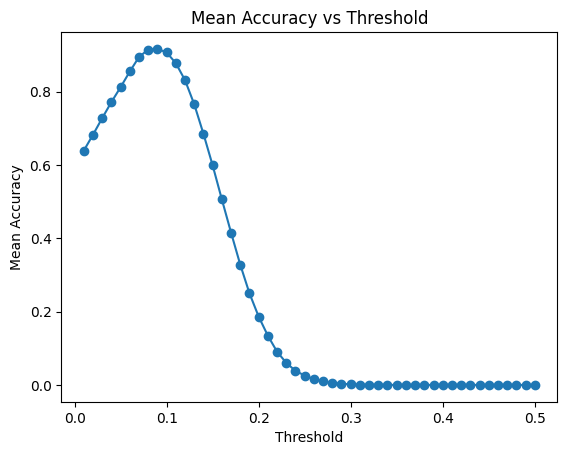

In [14]:
avg_acc = results_df.groupby('threshold')['accuracy'].mean().reset_index()
plt.plot(avg_acc['threshold'], avg_acc['accuracy'], marker='o')
plt.xlabel('Threshold')
plt.ylabel('Mean Accuracy')
plt.title('Mean Accuracy vs Threshold')
plt.show()